# Experiment v4: Optuna Hyperparameter Tuning

**목표**
- 최종 전처리(v2)로 확정된 상태에서 하이퍼파라미터 자동 튜닝
- XGBoost, LightGBM 각각 100 trials
- (F1+AUC)/2 기준 최적화
- threshold tuning까지 동일하게 적용

**비교 기준점**
- v2 + XGBoost(수동 튜닝) + threshold 0.42: **0.8319** (현재 best)

**전체 예상 소요시간**: 30~40분


## 0. 환경 셋업

In [1]:
!pip install optuna -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.6 MB/s eta 0:00:00


## 1. 데이터 로드 + v2 전처리

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# v2 전처리 (Unknown category)
cat_cols = ['workclass', 'education', 'marital_status', 'occupation',
            'relationship', 'race', 'sex', 'native_country']
for col in cat_cols:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

y_train = train_df["income"].map({"<=50K": 0, ">50K": 1})
test_id = test_df["id"]
train_features = train_df.drop(columns=["income", "id"])
test_features = test_df.drop(columns=["id"])
full_df = pd.concat([train_features, test_features], axis=0)
full_encoded = pd.get_dummies(full_df, columns=cat_cols)
X_train = full_encoded.iloc[:len(train_df)]
X_test = full_encoded.iloc[len(train_df):]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (39073, 107)
X_test shape: (9769, 107)


## 2. Train/Validation Split

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
print("train:", X_tr.shape, "  val:", X_val.shape)


train: (31258, 107)   val: (7815, 107)


## 3. XGBoost Optuna 튜닝

**탐색 범위**
- n_estimators: 200~1000
- max_depth: 3~10
- learning_rate: 0.01~0.3 (log scale)
- subsample, colsample_bytree: 0.6~1.0
- min_child_weight: 1~10
- gamma, reg_alpha, reg_lambda: 0~5 (regularization)

각 trial마다 5-fold CV 평균으로 평가. 100 trials = 약 15분 예상.

In [4]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # 로그 최소화

cv_for_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)

    # 5-fold CV로 F1, AUC 계산
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv_for_optuna, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv_for_optuna, scoring='roc_auc', n_jobs=-1)

    # 목표: (F1 + AUC) / 2 최대화
    return (f1_scores.mean() + auc_scores.mean()) / 2

print("XGBoost Optuna 튜닝 시작 (100 trials)...")
xgb_study = optuna.create_study(direction='maximize', study_name='xgb_v2')
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\n=== XGBoost 튜닝 결과 ===")
print(f"Best (F1+AUC)/2: {xgb_study.best_value:.4f}")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")


XGBoost Optuna 튜닝 시작 (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


=== XGBoost 튜닝 결과 ===
Best (F1+AUC)/2: 0.8212
Best params:
  n_estimators: 1000
  max_depth: 4
  learning_rate: 0.03700396073385101
  subsample: 0.8128296993602494
  colsample_bytree: 0.8114905987538509
  min_child_weight: 2
  gamma: 0.5524984091410132
  reg_alpha: 0.2672240999485271
  reg_lambda: 2.929634344529247


## 4. LightGBM Optuna 튜닝

**탐색 범위**
- n_estimators: 200~1000
- num_leaves: 15~127 (LightGBM 특화 파라미터, depth 대신)
- max_depth: 3~10
- learning_rate: 0.01~0.3 (log scale)
- subsample, colsample_bytree: 0.6~1.0
- min_child_samples: 5~50
- reg_alpha, reg_lambda: 0~5


In [5]:
from lightgbm import LGBMClassifier

def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)

    f1_scores = cross_val_score(model, X_train, y_train, cv=cv_for_optuna, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv_for_optuna, scoring='roc_auc', n_jobs=-1)

    return (f1_scores.mean() + auc_scores.mean()) / 2

print("LightGBM Optuna 튜닝 시작 (100 trials)...")
lgbm_study = optuna.create_study(direction='maximize', study_name='lgbm_v2')
lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

print(f"\n=== LightGBM 튜닝 결과 ===")
print(f"Best (F1+AUC)/2: {lgbm_study.best_value:.4f}")
print(f"Best params:")
for k, v in lgbm_study.best_params.items():
    print(f"  {k}: {v}")


LightGBM Optuna 튜닝 시작 (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


=== LightGBM 튜닝 결과 ===
Best (F1+AUC)/2: 0.8219
Best params:
  n_estimators: 800
  num_leaves: 85
  max_depth: 4
  learning_rate: 0.11132750013143437
  subsample: 0.846144545146749
  colsample_bytree: 0.710832083572799
  min_child_samples: 32
  reg_alpha: 0.8905166354084645
  reg_lambda: 4.318478971248461


## 5. Optuna 튜닝 결과 시각화

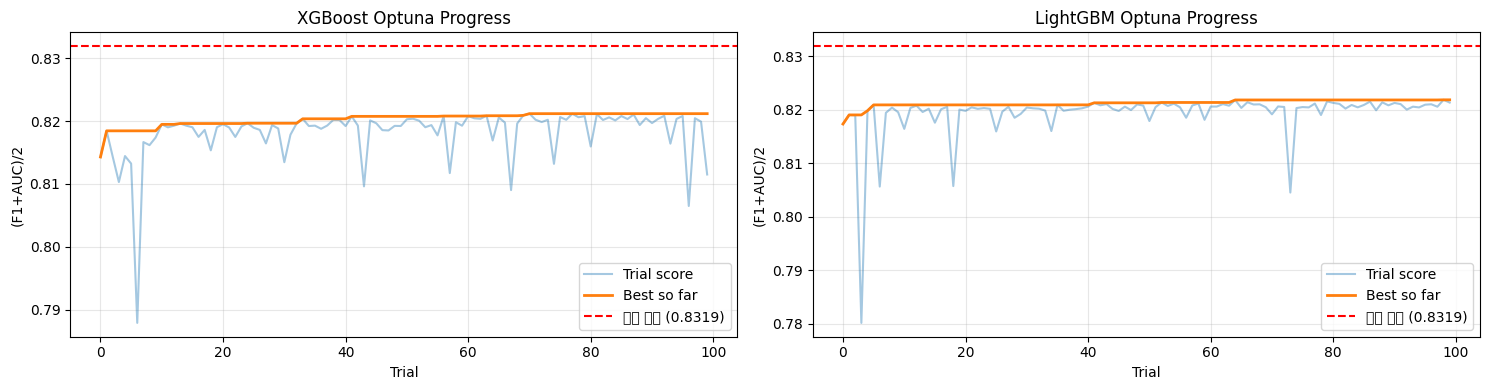

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# XGBoost 최적화 history
xgb_values = [trial.value for trial in xgb_study.trials]
xgb_best_so_far = np.maximum.accumulate(xgb_values)
axes[0].plot(xgb_values, alpha=0.4, label='Trial score')
axes[0].plot(xgb_best_so_far, linewidth=2, label='Best so far')
axes[0].axhline(y=0.8319, color='red', linestyle='--', label='수동 튜닝 (0.8319)')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('(F1+AUC)/2')
axes[0].set_title('XGBoost Optuna Progress')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LightGBM 최적화 history
lgbm_values = [trial.value for trial in lgbm_study.trials]
lgbm_best_so_far = np.maximum.accumulate(lgbm_values)
axes[1].plot(lgbm_values, alpha=0.4, label='Trial score')
axes[1].plot(lgbm_best_so_far, linewidth=2, label='Best so far')
axes[1].axhline(y=0.8319, color='red', linestyle='--', label='수동 튜닝 (0.8319)')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('(F1+AUC)/2')
axes[1].set_title('LightGBM Optuna Progress')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Best 모델로 Threshold Tuning

In [7]:
# 두 모델 중 더 나은 거 선택
if xgb_study.best_value >= lgbm_study.best_value:
    best_model_name = "XGBoost (Optuna)"
    best_params = xgb_study.best_params
    best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'eval_metric': 'logloss'})
    best_model = XGBClassifier(**best_params)
else:
    best_model_name = "LightGBM (Optuna)"
    best_params = lgbm_study.best_params
    best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
    best_model = LGBMClassifier(**best_params)

print(f"Best model: {best_model_name}")
print(f"Best CV (F1+AUC)/2: {max(xgb_study.best_value, lgbm_study.best_value):.4f}")

# 단일 split으로 학습 후 threshold tuning
best_model.fit(X_tr, y_tr)
y_val_prob = best_model.predict_proba(X_val)[:, 1]


Best model: LightGBM (Optuna)
Best CV (F1+AUC)/2: 0.8219


In [8]:
# Threshold scan
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"기본 threshold (0.5) F1: {f1_score(y_val, (y_val_prob >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.4f}")


기본 threshold (0.5) F1: 0.7172
Best threshold: 0.44
Best F1: 0.7315


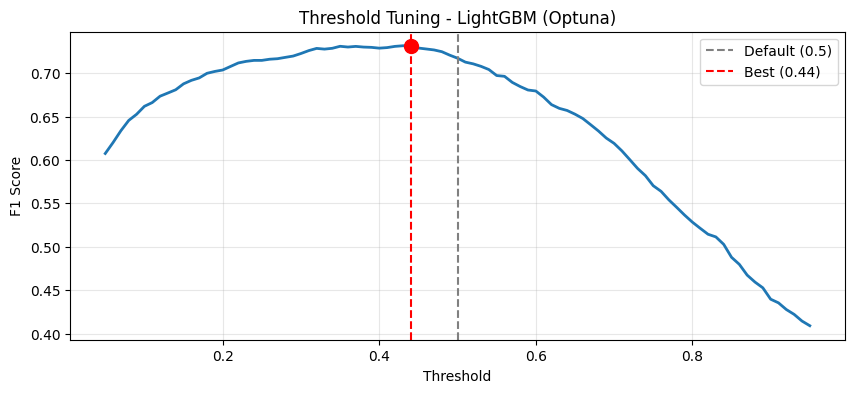

In [9]:
# Threshold tuning 시각화
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [10]:
# 최종 점수
y_val_pred_tuned = (y_val_prob >= best_threshold).astype(int)
f1_tuned = f1_score(y_val, y_val_pred_tuned)
auc_tuned = roc_auc_score(y_val, y_val_prob)
score_tuned = (f1_tuned + auc_tuned) / 2

print(f"[{best_model_name} + Threshold {best_threshold:.2f}]")
print(f"  F1 = {f1_tuned:.4f}")
print(f"  AUC = {auc_tuned:.4f}")
print(f"  (F1+AUC)/2 = {score_tuned:.4f}")


[LightGBM (Optuna) + Threshold 0.44]
  F1 = 0.7315
  AUC = 0.9303
  (F1+AUC)/2 = 0.8309


## 7. 전체 결과 비교

In [11]:
results_df = pd.DataFrame([
    {"실험": "v2 + 수동 튜닝", "Threshold": 0.42, "(F1+AUC)/2": 0.8319},
    {"실험": "v3-a + 수동 튜닝", "Threshold": 0.44, "(F1+AUC)/2": 0.8323},
    {"실험": "v3 + 수동 튜닝", "Threshold": 0.41, "(F1+AUC)/2": 0.8286},
    {"실험": f"v2 + XGBoost Optuna", "Threshold": "—", "(F1+AUC)/2": round(xgb_study.best_value, 4)},
    {"실험": f"v2 + LightGBM Optuna", "Threshold": "—", "(F1+AUC)/2": round(lgbm_study.best_value, 4)},
    {"실험": f"v2 + Optuna + threshold", "Threshold": round(best_threshold, 2), "(F1+AUC)/2": round(score_tuned, 4)},
])

print(results_df.to_string(index=False))

# 향상 측정
prev_best = 0.8323
final_best = score_tuned
diff = final_best - prev_best
print(f"\n이전 best (v3-a, 0.8323) → Optuna best ({final_best:.4f}): {'+' if diff >= 0 else ''}{diff:.4f}")


                     실험 Threshold  (F1+AUC)/2
             v2 + 수동 튜닝      0.42      0.8319
           v3-a + 수동 튜닝      0.44      0.8323
             v3 + 수동 튜닝      0.41      0.8286
    v2 + XGBoost Optuna         —      0.8212
   v2 + LightGBM Optuna         —      0.8219
v2 + Optuna + threshold      0.44      0.8309

이전 best (v3-a, 0.8323) → Optuna best (0.8309): -0.0014


## 8. prediction.csv 생성 (조건부)

In [12]:
# Optuna 결과가 이전 best(0.8323)보다 좋을 때만 prediction.csv 업데이트
if score_tuned > 0.8323:
    print(f"Optuna 결과가 이전 best보다 좋음 ({score_tuned:.4f} > 0.8323) → prediction.csv 업데이트")

    # 전체 train으로 final 모델 재학습
    if best_model_name == "XGBoost (Optuna)":
        final_params = xgb_study.best_params.copy()
        final_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'eval_metric': 'logloss'})
        final_model = XGBClassifier(**final_params)
    else:
        final_params = lgbm_study.best_params.copy()
        final_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
        final_model = LGBMClassifier(**final_params)

    final_model.fit(X_train, y_train)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    prediction = pd.DataFrame({
        "id": test_id.values,
        "y_cls": y_test_pred,
        "y_prob": y_test_prob
    })
    prediction.to_csv("prediction.csv", index=False)
    print(f"prediction.csv saved, {len(prediction)} rows")
    print(f"y_cls 분포: {prediction['y_cls'].value_counts().to_dict()}")
else:
    print(f"Optuna 결과가 이전 best 이하 ({score_tuned:.4f} <= 0.8323) → prediction.csv 유지")


Optuna 결과가 이전 best 이하 (0.8309 <= 0.8323) → prediction.csv 유지


## 9. Best params 저장 (보고서/재현용)

In [13]:
# 보고서에 쓸 수 있도록 best params 출력
print("="*60)
print("XGBoost Best Hyperparameters")
print("="*60)
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

print("\n" + "="*60)
print("LightGBM Best Hyperparameters")
print("="*60)
for k, v in lgbm_study.best_params.items():
    print(f"  {k}: {v}")

print(f"\nFinal threshold: {best_threshold:.2f}")
print(f"Final score: {score_tuned:.4f}")


XGBoost Best Hyperparameters
  n_estimators: 1000
  max_depth: 4
  learning_rate: 0.03700396073385101
  subsample: 0.8128296993602494
  colsample_bytree: 0.8114905987538509
  min_child_weight: 2
  gamma: 0.5524984091410132
  reg_alpha: 0.2672240999485271
  reg_lambda: 2.929634344529247

LightGBM Best Hyperparameters
  n_estimators: 800
  num_leaves: 85
  max_depth: 4
  learning_rate: 0.11132750013143437
  subsample: 0.846144545146749
  colsample_bytree: 0.710832083572799
  min_child_samples: 32
  reg_alpha: 0.8905166354084645
  reg_lambda: 4.318478971248461

Final threshold: 0.44
Final score: 0.8309
